In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_state = pd.read_excel("phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx", sheet_name = "State_Txn and Users")
df_split = pd.read_excel("phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx", sheet_name ="State_TxnSplit") 
df_device = pd.read_excel("phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx", sheet_name ="State_DeviceData")
df_dist = pd.read_excel("phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx", sheet_name="District_Txn and Users")
df_dist_demo = pd.read_excel("phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx", sheet_name ="District Demographics")

print("Dataset Loaded Sucessfully")

Dataset Loaded Sucessfully


<h5><center> Task 1: Data Loading and Understanding 

In [4]:
df_state.head()                 # First five rows of State_Txn_users

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [5]:
df_split.tail(10)               # Last 10 rows of State_TxnSplit

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


In [6]:
middle =len(df_device) //2              # finding middle row
df_device.iloc[middle-5 : middle+5]

,State,Year,Quarter,Brand,Registered Users,Percentage
2767,Ladakh,2021,2,OnePlus,1741,0.023198
2768,Ladakh,2021,2,Motorola,922,0.012285
2769,Ladakh,2021,2,Huawei,894,0.011912
2770,Ladakh,2021,2,Lenovo,490,0.006529
2771,Ladakh,2021,2,Others,2610,0.034778
2772,Lakshadweep,2018,1,Samsung,102,0.203593
2773,Lakshadweep,2018,1,Xiaomi,100,0.199601
2774,Lakshadweep,2018,1,Vivo,67,0.133733
2775,Lakshadweep,2018,1,Oppo,56,0.111776
2776,Lakshadweep,2018,1,Huawei,25,0.049900


In [7]:
print(df_dist.head(10))
print(df_dist.tail(10))                 # First 10 and Last 10 rows of District_Txn_Users

                       State  Year  Quarter                  District  Code  \
0  Andaman & Nicobar Islands  2018        1                  Nicobars  AN01   
1  Andaman & Nicobar Islands  2018        1  North And Middle Andaman  AN02   
2  Andaman & Nicobar Islands  2018        1             South Andaman  AN03   
3  Andaman & Nicobar Islands  2018        2                  Nicobars  AN01   
4  Andaman & Nicobar Islands  2018        2  North And Middle Andaman  AN02   
5  Andaman & Nicobar Islands  2018        2             South Andaman  AN03   
6  Andaman & Nicobar Islands  2018        3                  Nicobars  AN01   
7  Andaman & Nicobar Islands  2018        3  North And Middle Andaman  AN02   
8  Andaman & Nicobar Islands  2018        3             South Andaman  AN03   
9  Andaman & Nicobar Islands  2018        4                  Nicobars  AN01   

   Transactions  Amount (INR)    ATV (INR)  Registered Users  App Opens  
0           528  1.139849e+06  2158.804548              

In [8]:
df_dist_demo.iloc[::10]             # Every 10th rows of District Demographic

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161.0,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.0,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.0,520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.0,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,3097.0,596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.0,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.0,14557,DL04,North


----------

<h5> <center> Basic Stat and Data Types

----------

In [9]:
df_state.describe()                         # Only works on numerical columns

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,504.000000,504.000000,5.040000e+02,5.030000e+02,504.000000,5.040000e+02,5.040000e+02
mean,2019.285714,2.357143,4.074000e+07,7.083332e+10,1993.471543,4.777501e+06,9.774471e+07
std,1.031181,1.109971,8.228714e+07,1.440902e+11,607.464894,6.644496e+06,2.042376e+08
min,2018.000000,1.000000,7.780000e+02,1.928611e+06,0.000000,5.010000e+02,0.000000e+00
25%,2018.000000,1.000000,5.925578e+05,1.167157e+09,1598.910667,1.574202e+05,0.000000e+00
50%,2019.000000,2.000000,6.217487e+06,1.051605e+10,1861.380589,1.747914e+06,2.930574e+06
75%,2020.000000,3.000000,4.363675e+07,6.947045e+10,2259.087924,7.320945e+06,8.615022e+07
max,2021.000000,4.000000,5.736165e+08,1.027958e+12,3938.733850,3.966470e+07,1.208084e+09


In [10]:
df_state.dtypes                 # data type of each column, int64 = whole numbers, float64 = decimal numbers, objects = string/ text

State                object
Year                  int64
Quarter               int64
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

In [11]:
df_split.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR)
count,2514.000000,2514.000000,2.514000e+03,2.514000e+03,2514.000000
mean,2019.286794,2.358393,8.167446e+06,1.443978e+10,1349.927929
std,1.030807,1.109251,2.423645e+07,5.995054e+10,1534.866221
min,2018.000000,1.000000,2.000000e+00,3.439721e+01,17.198606
25%,2018.000000,1.000000,2.788075e+04,1.762412e+07,385.735827
50%,2019.000000,2.000000,2.687980e+05,1.901189e+08,720.940406
75%,2020.000000,3.000000,3.683230e+06,2.661248e+09,1352.790116
max,2021.000000,4.000000,2.795990e+08,8.721520e+11,7767.539936


In [12]:
df_split.dtypes

State                object
Year                  int64
Quarter               int64
Transaction Type     object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
dtype: object

In [13]:
df_device.describe()

,Year,Quarter,Registered Users,Percentage
count,5544.000000,5544.000000,5.544000e+03,5544.000000
mean,2019.285714,2.357143,4.343183e+05,0.090909
std,1.030250,1.108970,9.056069e+05,0.083095
min,2018.000000,1.000000,1.000000e+01,0.006373
25%,2018.000000,1.000000,8.055750e+03,0.021588
50%,2019.000000,2.000000,7.442250e+04,0.056914
75%,2020.000000,3.000000,3.978875e+05,0.143626
max,2021.000000,4.000000,9.764252e+06,0.478367


In [14]:
df_device.dtypes

State                object
Year                  int64
Quarter               int64
Brand                object
Registered Users      int64
Percentage          float64
dtype: object

In [15]:
df_dist.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,10248.000000,10248.000000,1.024800e+04,1.024800e+04,10244.000000,1.024800e+04,1.024800e+04
mean,2019.285714,2.357143,2.003607e+06,3.542311e+09,1909.796545,2.349591e+05,4.807117e+06
std,1.030208,1.108924,9.613466e+06,1.473154e+10,600.943349,4.605978e+05,1.562541e+07
min,2018.000000,1.000000,0.000000e+00,0.000000e+00,84.944283,2.200000e+01,0.000000e+00
25%,2018.000000,1.000000,1.031418e+05,1.756668e+08,1554.589051,3.619550e+04,0.000000e+00
50%,2019.000000,2.000000,3.763065e+05,6.784562e+08,1863.135530,1.067640e+05,6.403025e+05
75%,2020.000000,3.000000,1.272815e+06,2.377256e+09,2203.083552,2.573165e+05,4.346320e+06
max,2021.000000,4.000000,3.487128e+08,4.444224e+11,11209.980550,1.060461e+07,5.544197e+08


In [16]:
df_dist.dtypes

State                object
Year                  int64
Quarter               int64
District             object
Code                 object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

In [17]:
df_dist_demo.describe()

,Population,Area (sq km),Density
count,7.420000e+02,742.000000,742.000000
mean,1.668555e+06,4395.373120,838.512129
std,1.458849e+06,4254.676124,2754.406896
min,0.000000e+00,0.000000,0.000000
25%,6.530815e+05,2039.750000,198.000000
50%,1.322359e+06,3402.500000,353.000000
75%,2.297440e+06,5432.750000,686.250000
max,1.008285e+07,45652.000000,36155.000000


In [18]:
df_dist_demo.dtypes

State              object
District           object
Headquarters       object
Population          int64
Area (sq km)      float64
Density             int64
Code               object
Alternate Name     object
dtype: object

----------

<h5><center> Checkin Missing Values

__________________________________________

In [19]:
print(df_state.isnull().sum())                          # .isnull() returns true for null values and sum() counts the how many True values are there
print(df_split.isnull().sum())
print(df_device.isnull().sum())
print(df_dist.isnull().sum())
print(df_dist_demo.isnull().sum())

State               0
Year                0
Quarter             0
Transactions        0
Amount (INR)        1
ATV (INR)           0
Registered Users    0
App Opens           0
dtype: int64
State               0
Year                0
Quarter             0
Transaction Type    0
Transactions        0
Amount (INR)        0
ATV (INR)           0
dtype: int64
State               0
Year                0
Quarter             0
Brand               0
Registered Users    0
Percentage          0
dtype: int64
State                0
Year                 0
Quarter              0
District             0
Code                28
Transactions         0
Amount (INR)         0
ATV (INR)            4
Registered Users     0
App Opens            0
dtype: int64
State             0
District          0
Headquarters      0
Population        0
Area (sq km)      0
Density           0
Code              0
Alternate Name    0
dtype: int64


In [20]:
# finding percentage of missing values in each column
missing_percent_state =df_state.isnull().sum() / len(df_state) *100
print(missing_percent_state)                      # percentage of missing values

State               0.000000
Year                0.000000
Quarter             0.000000
Transactions        0.000000
Amount (INR)        0.198413
ATV (INR)           0.000000
Registered Users    0.000000
App Opens           0.000000
dtype: float64


In [ ]:
print("Highest Missing Column:",missing_percent_state.idxmax())                 # idxmax() returns name of column with highest value
print("Missing Percentage:",missing_percent_state.max())                        # max() returns highest value itself

Highest Missing Column: Amount (INR)
Missing Percentage: 0.1984126984126984


In [22]:
missing_percent_dist = df_dist.isnull().sum() / len(df_dist) *100
print(missing_percent_dist)

State               0.000000
Year                0.000000
Quarter             0.000000
District            0.000000
Code                0.273224
Transactions        0.000000
Amount (INR)        0.000000
ATV (INR)           0.039032
Registered Users    0.000000
App Opens           0.000000
dtype: float64


In [23]:
print("Highest Missing Value Column:",missing_percent_dist.idxmax())
print("Missing Percentage:",missing_percent_dist.max())

Highest Missing Value Column: Code
Missing Percentage: 0.273224043715847


<h5> <center> Summary

In [ ]:
# Finding different states in dataset
total_states = df_state['State'].nunique()              # counts how many unique values are there in a column
print("Total States =",total_states)

Total States = 36


In [25]:
total_districts = df_dist['District'].nunique()
print("Total Districts =",total_districts)

Total Districts = 723


In [ ]:
# finding total districts in each state
district_count = df_dist.groupby("State")['District'].nunique()                 # groupby groups all state that have same name, and counts unique districts in each state
print(district_count)

State
Andaman & Nicobar Islands                3
Andhra Pradesh                          13
Arunachal Pradesh                       25
Assam                                   33
Bihar                                   38
Chandigarh                               1
Chhattisgarh                            27
Dadra & Nagar Haveli and Daman & Diu     3
Delhi                                   11
Goa                                      2
Gujarat                                 33
Haryana                                 22
Himachal Pradesh                        12
Jammu & Kashmir                         22
Jharkhand                               24
Karnataka                               30
Kerala                                  14
Ladakh                                   2
Lakshadweep                              1
Madhya Pradesh                          52
Maharashtra                             36
Manipur                                 16
Meghalaya                               11
Mizor

In [27]:
state_most_districts= district_count.idxmax()
print("State with most districts:", state_most_districts)

State with most districts: Uttar Pradesh


__________

In [28]:
print("Number of Districts:",district_count.max())

Number of Districts: 75


<h5> <center> Task 2 : Exploratory Data Analysis

___________

In [29]:
state_totals = df_state.groupby("State")[["Transactions","Amount (INR)"]].sum()
pd.options.display.float_format = '{:,.0f}'.format          # for displaying this kinda (3.641818e+09) no. to this  3,641,817,861
print(state_totals)

                                      Transactions      Amount (INR)
State                                                               
Andaman & Nicobar Islands                  1223565     3,641,817,861
Andhra Pradesh                          1781091169 3,187,847,468,852
Arunachal Pradesh                          8043799    22,251,830,957
Assam                                    123577981   281,408,712,657
Bihar                                    713643889 1,639,578,926,752
Chandigarh                                25516542    53,712,084,631
Chhattisgarh                             241908549   415,635,319,208
Dadra & Nagar Haveli and Daman & Diu      12462185    18,658,784,568
Delhi                                   1011031124 1,649,942,211,116
Goa                                       24481604    44,271,871,113
Gujarat                                  612992823 1,105,328,681,947
Haryana                                  567751410 1,059,831,565,200
Himachal Pradesh                  

In [30]:
state_totals_sorted = state_totals.sort_values("Transactions", ascending = False)

print("Top 5 states: \n",state_totals_sorted.head())
print("\n \nBottom 5 states:\n",state_totals_sorted.tail())

Top 5 states: 
                 Transactions      Amount (INR)
State                                         
Karnataka         2981044533 4,361,395,878,908
Maharashtra       2833670154 4,290,995,253,332
Telangana         2347430243 4,574,245,879,738
Andhra Pradesh    1781091169 3,187,847,468,852
Rajasthan         1382918930 2,625,584,351,281

 
Bottom 5 states:
                            Transactions   Amount (INR)
State                                                 
Meghalaya                       5648913 12,541,621,895
Mizoram                         2162776  6,317,141,435
Ladakh                          1880109  6,606,978,450
Andaman & Nicobar Islands       1223565  3,641,817,861
Lakshadweep                       71610    192,158,685


In [31]:
df_split_sorted= df_split.sort_values("Transactions", ascending =False)
most_common = df_split_sorted.groupby(['State','Quarter']).first().reset_index()
print(most_common[["State","Quarter","Transaction Type", "Transactions"]])

                         State  Quarter          Transaction Type  \
0    Andaman & Nicobar Islands        1     Peer-to-peer payments   
1    Andaman & Nicobar Islands        2     Peer-to-peer payments   
2    Andaman & Nicobar Islands        3  Recharge & bill payments   
3    Andaman & Nicobar Islands        4     Peer-to-peer payments   
4               Andhra Pradesh        1     Peer-to-peer payments   
..                         ...      ...                       ...   
139                Uttarakhand        4     Peer-to-peer payments   
140                West Bengal        1     Peer-to-peer payments   
141                West Bengal        2     Peer-to-peer payments   
142                West Bengal        3     Peer-to-peer payments   
143                West Bengal        4     Peer-to-peer payments   

     Transactions  
0          105458  
1          132772  
2           59310  
3           81439  
4       149313738  
..            ...  
139       6748183  
140      53

In [32]:
# Device brand with highest registered Users/state
df_device_sorted = df_device.sort_values("Registered Users", ascending = False)
top_brand=df_device_sorted.groupby("State").first().reset_index()
print(top_brand[['State',"Brand","Registered Users"]])

                                   State    Brand  Registered Users
0              Andaman & Nicobar Islands     Vivo             15056
1                         Andhra Pradesh   Xiaomi           4937684
2                      Arunachal Pradesh     Vivo             63439
3                                  Assam   Xiaomi            909274
4                                  Bihar   Xiaomi           4268361
5                             Chandigarh   Xiaomi            101761
6                           Chhattisgarh     Vivo           1169224
7   Dadra & Nagar Haveli and Daman & Diu     Vivo             87001
8                                  Delhi   Xiaomi           2731995
9                                    Goa   Xiaomi            152107
10                               Gujarat     Vivo           3834323
11                               Haryana   Xiaomi           2505880
12                      Himachal Pradesh   Xiaomi            513196
13                       Jammu & Kashmir   Xiaom

In [33]:
# Top district per state by population
df_dist_demo_sorted = df_dist_demo.sort_values("Population" ,ascending =False)
top_district = df_dist_demo_sorted.groupby("State").first().reset_index()
print(top_district[['State','District',"Population"]])

                                   State                District  Population
0              Andaman & Nicobar Islands           South Andaman      238142
1                         Andhra Pradesh           East Godavari     5151549
2                      Arunachal Pradesh              Papum Pare      176385
3                                  Assam                  Nagaon     2826006
4                                  Bihar                   Patna     5772804
5                             Chandigarh              Chandigarh     1055450
6                           Chhattisgarh                  Raipur     2160876
7   Dadra & Nagar Haveli and Daman & Diu  Dadra and Nagar Haveli      343709
8                                  Delhi        North West Delhi     3656539
9                                    Goa               North Goa      817761
10                               Gujarat               Ahmedabad     7208200
11                               Haryana               Faridabad     1798954

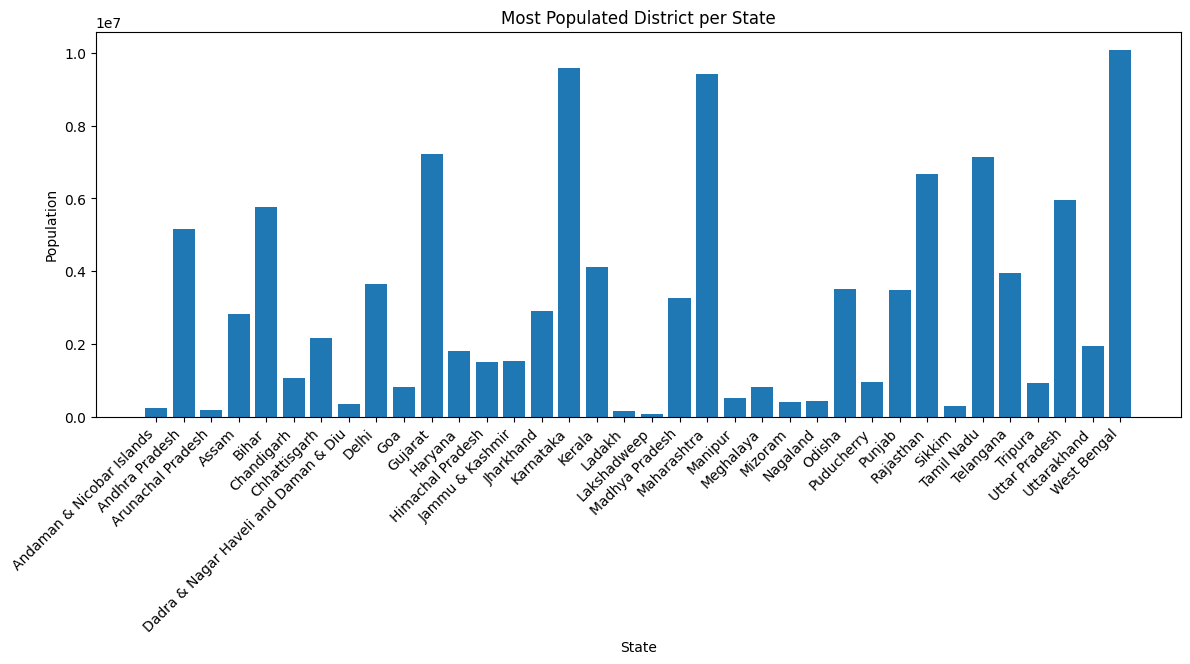

In [34]:
plt.figure(figsize=(14,5))
plt.bar(top_district['State'],top_district['Population'])
plt.xlabel("State")
plt.ylabel("Population")
plt.title("Most Populated District per State")
plt.xticks(rotation=45, ha ='right')
plt.show()

In [35]:
# Average Transaction Value per state
atv_by_state = df_state.groupby("State")['ATV (INR)'].mean()
atv_by_state = atv_by_state.sort_values(ascending=False)
print(atv_by_state)

State
Ladakh                                 3,408
Andaman & Nicobar Islands              3,159
Mizoram                                2,928
Lakshadweep                            2,776
Arunachal Pradesh                      2,638
Manipur                                2,621
Nagaland                               2,610
Jammu & Kashmir                        2,509
Chandigarh                             2,114
Sikkim                                 2,088
Punjab                                 2,085
Meghalaya                              2,056
Bihar                                  2,023
Assam                                  2,008
Puducherry                             1,928
Goa                                    1,895
Tamil Nadu                             1,861
Telangana                              1,843
Haryana                                1,832
Himachal Pradesh                       1,825
Rajasthan                              1,758
Andhra Pradesh                         1,748
Guja

In [36]:
print("Top 5 states - Highest ATV:\n", atv_by_state.head())
print("\n\nBottom 5 states - Lowest ATV:\n", atv_by_state.tail())

Top 5 states - Highest ATV:
 State
Ladakh                      3,408
Andaman & Nicobar Islands   3,159
Mizoram                     2,928
Lakshadweep                 2,776
Arunachal Pradesh           2,638
Name: ATV (INR), dtype: float64


Bottom 5 states - Lowest ATV:
 State
Karnataka                              1,517
Maharashtra                            1,516
Dadra & Nagar Haveli and Daman & Diu   1,487
Odisha                                 1,428
West Bengal                            1,374
Name: ATV (INR), dtype: float64


In [37]:
# App Usage Trend
app_opens = df_state.groupby(["State","Year","Quarter"])["App Opens"].sum()
print(app_opens)

State                      Year  Quarter
Andaman & Nicobar Islands  2018  1                  0
                                 2                  0
                                 3                  0
                                 4                  0
                           2019  1                  0
                                              ...    
West Bengal                2020  2          198589332
                                 3          246554831
                                 4          291721919
                           2021  1          316832674
                                 2          275341466
Name: App Opens, Length: 504, dtype: int64


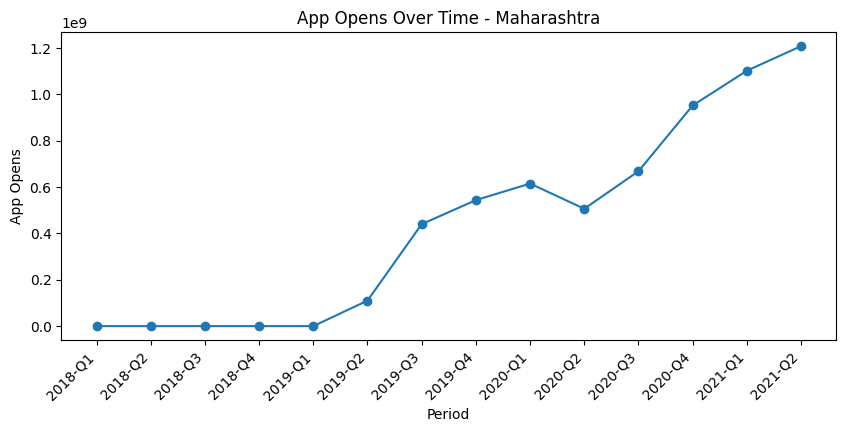

In [38]:
# filterinng for Maharashtra 
my_state = "Maharashtra"
state_data = df_state[df_state["State"]==my_state].copy()

# creating period label like "2018-Q1"
state_data["Period"] = state_data['Year'].astype(str) + "-Q" + state_data["Quarter"].astype(str)
state_data = state_data.sort_values(["Year","Quarter"])

plt.figure(figsize =(10,4))
plt.plot(state_data["Period"], state_data["App Opens"], marker = 'o')
plt.xlabel("Period")
plt.ylabel("App Opens")
plt.title(f"App Opens Over Time - {my_state}")
plt.xticks(rotation =45, ha='right')
plt.show()

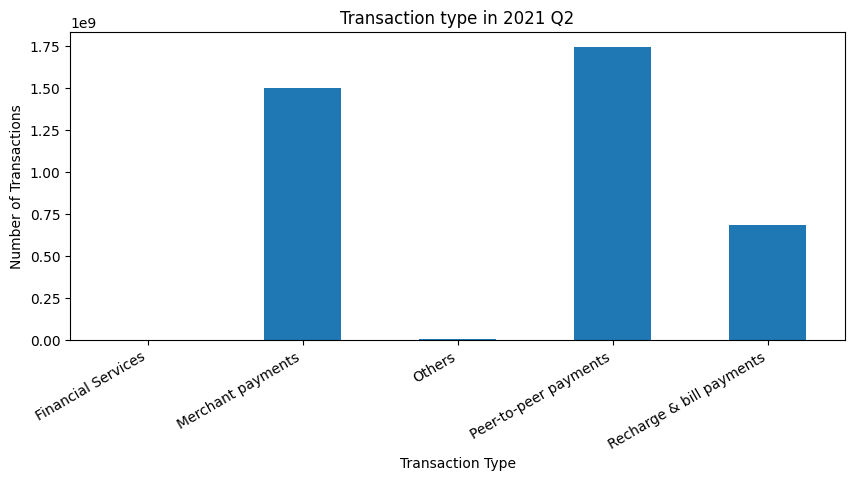

In [39]:
# Distribution of transaction types
latest_year =df_split['Year'].max()
latest_quarter = df_split[df_split['Year']==latest_year]['Quarter'].max()

recent_data = df_split[df_split["Year"]==latest_year]
recent_data = recent_data[recent_data["Quarter"]==latest_quarter]

txn_by_type = recent_data.groupby("Transaction Type")["Transactions"].sum()

plt.figure(figsize = (10,4))
txn_by_type.plot(kind ='bar')
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.title(f"Transaction type in {latest_year} Q{latest_quarter}")
plt.xticks(rotation= 30, ha ='right')
plt.show()

In [40]:
# Unique District name to district code mapping
district_map = df_dist[["District","Code"]].drop_duplicates()
print(district_map)

                        District  Code
0                       Nicobars  AN01
1       North And Middle Andaman  AN02
2                  South Andaman  AN03
42                     Anantapur  AP01
43                      Chittoor  AP02
...                          ...   ...
9944             Purba Bardhaman  WB19
9945             Purba Medinipur  WB20
9946                     Purulia  WB21
9947  South Twenty Four Parganas  WB22
9948              Uttar Dinajpur  WB23

[732 rows x 2 columns]


In [41]:
district_map.to_csv("district_code_mapping.csv", index=False)
print(" CSV SAVED ")

 CSV SAVED 


___

<h5><center> Task 3: Data Quality Check

______

In [42]:
# checking data consistency
# sum dist data by state, year, quarter
dist_sum = df_dist.groupby(['State', 'Year','Quarter'])[['Transactions','Amount (INR)', 'Registered Users']].sum().reset_index()

# Merge with state data
merged = dist_sum.merge(df_state[['State','Year','Quarter','Transactions','Amount (INR)','Registered Users']], on=['State','Year','Quarter'])

# Finding Difference
merged['Txn_Diff'] = merged['Transactions_x'] - merged['Transactions_y']
merged['Amt_Diff'] = merged['Amount (INR)_x'] - merged['Amount (INR)_y']
merged['Users_Diff'] = merged['Registered Users_x'] - merged['Registered Users_y']

discrepancy = merged[(merged['Txn_Diff'] !=0) | (merged['Amt_Diff'] !=0) |(merged['Users_Diff']!=0)]

print("Total discrepancies found:",len(discrepancy))
print(discrepancy[['State','Year','Quarter', 'Txn_Diff', 'Amt_Diff','Users_Diff']])

Total discrepancies found: 491
                         State  Year  Quarter  Txn_Diff  Amt_Diff  Users_Diff
0    Andaman & Nicobar Islands  2018        1         0         0           0
1    Andaman & Nicobar Islands  2018        2         0         0           0
2    Andaman & Nicobar Islands  2018        3         0        -0           0
3    Andaman & Nicobar Islands  2018        4         0         0           0
5    Andaman & Nicobar Islands  2019        2         0        -0           0
..                         ...   ...      ...       ...       ...         ...
499                West Bengal  2020        2         0        -0           0
500                West Bengal  2020        3         0        -0           0
501                West Bengal  2020        4         0         0           0
502                West Bengal  2021        1         0         0           0
503                West Bengal  2021        2         0        -0           0

[491 rows x 6 columns]


In [43]:
# It seems like all differences are 0 and -0 (which considers as floating point), so are taking absolute value here

discrepancy= merged[(merged['Txn_Diff'].abs()>1) | 
                    (merged['Amt_Diff'].abs()>1) |
                    (merged['Users_Diff'].abs()>1)]
print("Total real discrepancies found :", len(discrepancy))

Total real discrepancies found : 0


________

<h5> <center> Task 4 : Data Merging and Advanced analysis

______

In [44]:
# total population per state from demographic
popu_by_state = df_dist_demo.groupby('State')['Population'].sum().reset_index()

# max registered users per state
users_by_state = df_state.groupby('State')['Registered Users'].max().reset_index()

#Merging both
merged_popu = users_by_state.merge(popu_by_state, on='State')

merged_popu['Ratio'] = merged_popu['Registered Users'] / merged_popu['Population']
print(merged_popu[['State','Registered Users','Population','Ratio']])

                                   State  Registered Users  Population  Ratio
0              Andaman & Nicobar Islands             62095      380581      0
1                         Andhra Pradesh          19620905    49378776      0
2                      Arunachal Pradesh            270572     1606047      0
3                                  Assam           3617056    34461385      0
4                                  Bihar          14972134   103817951      0
5                             Chandigarh            448572     1055450      0
6                           Chhattisgarh           4837055    25867958      0
7   Dadra & Nagar Haveli and Daman & Diu            344994      586956      1
8                                  Delhi          11182699    16787941      1
9                                    Goa            609106     1457723      0
10                               Gujarat          15735981    65930328      0
11                               Haryana          10530594    25

In [45]:
pd.options.display.float_format = '{:.4f}'.format
print(merged_popu[['State','Registered Users','Population','Ratio']].sort_values('Ratio',ascending =False))

                                   State  Registered Users  Population  Ratio
8                                  Delhi          11182699    16787941 0.6661
7   Dadra & Nagar Haveli and Daman & Diu            344994      586956 0.5878
31                             Telangana          18306880    36366570 0.5034
5                             Chandigarh            448572     1055450 0.4250
15                             Karnataka          25751023    60965960 0.4224
9                                    Goa            609106     1457723 0.4178
11                               Haryana          10530594    25855357 0.4073
1                         Andhra Pradesh          19620905    49378776 0.3974
20                           Maharashtra          39664697   112378989 0.3530
34                           Uttarakhand           3004040    10116752 0.2969
26                            Puducherry            369961     1247953 0.2965
29                                Sikkim            171740      

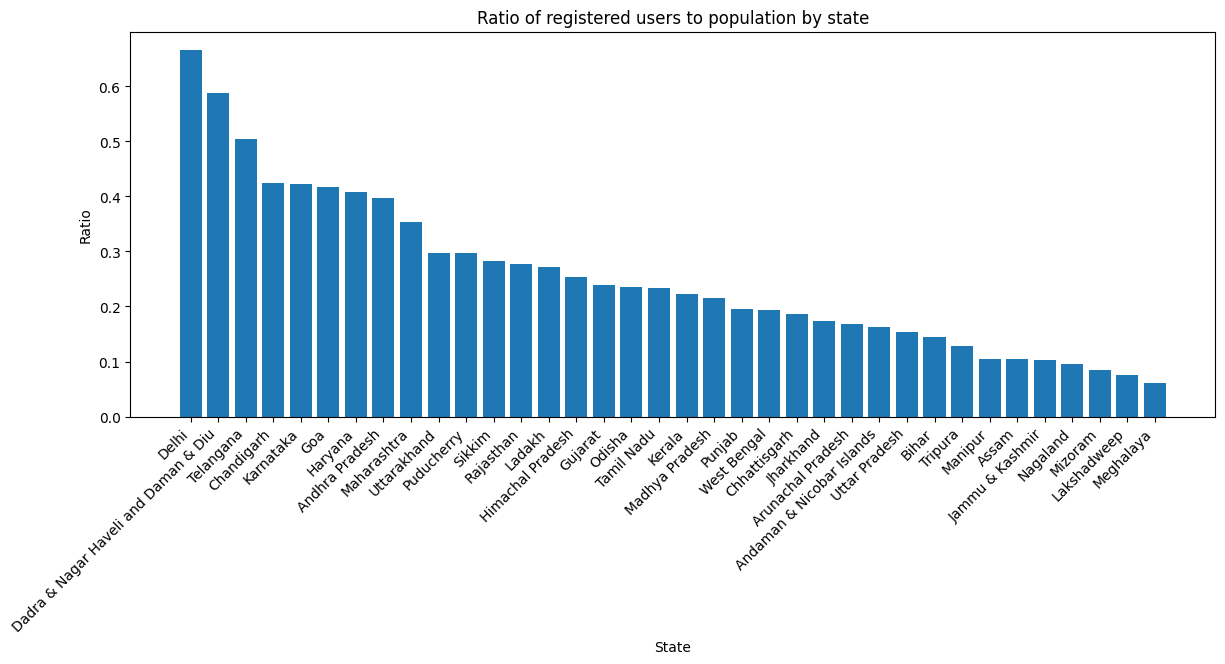

In [46]:
merged_popu_sorted = merged_popu.sort_values('Ratio',ascending=False)

plt.figure(figsize=(14,5))
plt.bar(merged_popu_sorted['State'], merged_popu_sorted['Ratio'])
plt.xlabel('State')
plt.ylabel('Ratio')
plt.title('Ratio of registered users to population by state')
plt.xticks(rotation =45 , ha ='right')
plt.show()

In [47]:
# Correlation between population density and transaction volume
dist_merged =df_dist.merge(df_dist_demo[['District','Code','Density']],on=['District','Code'])

dist_txn = dist_merged.groupby('District')[['Transactions','Density']].sum()

correlation = dist_txn['Density'].corr(dist_txn['Transactions'])
print('Correlation:',round(correlation,4))

Correlation: 0.4194


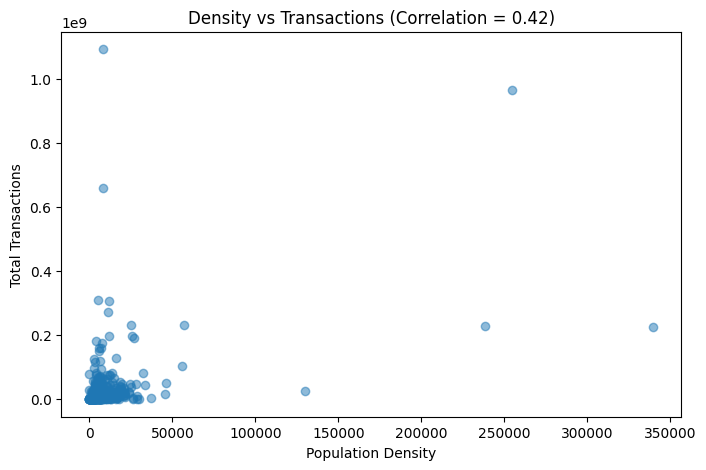

In [48]:
plt.figure(figsize =(8,5))
plt.scatter(dist_txn['Density'],dist_txn['Transactions'],alpha =0.5)
plt.xlabel('Population Density')
plt.ylabel('Total Transactions')
plt.title(f"Density vs Transactions (Correlation = 0.42)")
plt.show()

In [49]:
# Average Transaction amount per user by state

latest_state = df_state[(df_state['Year']==latest_year) & (df_state['Quarter']==latest_quarter)]
latest_state = latest_state.copy()
latest_state['Amt_Per_User'] =latest_state['Amount (INR)'] / latest_state['Registered Users']

result=latest_state[['State','Amt_Per_User']].sort_values("Amt_Per_User",ascending =False)
print(result)

print("\n Top 5:",result.head())
print("\n Bottom 5:",result.tail())

                                    State  Amt_Per_User
447                             Telangana    56151.4760
27                         Andhra Pradesh    43358.7288
223                             Karnataka    32538.0142
405                             Rajasthan    29592.9197
279                        Madhya Pradesh    26692.3344
125                                 Delhi    25212.2585
69                                  Bihar    25018.4947
363                                Odisha    24857.2841
307                               Manipur    23523.0061
293                           Maharashtra    23071.2731
167                               Haryana    19026.2158
251                                Ladakh    19017.9498
83                             Chandigarh    18765.4912
209                             Jharkhand    18316.6865
195                       Jammu & Kashmir    18087.9666
377                            Puducherry    17566.2697
41                      Arunachal Pradesh    164

In [50]:
# Device brand ratio per state

total_users = latest_state[['State','Registered Users']].copy()
total_users.columns = ['State','Total_Users']

device_merged =df_device.merge(total_users, on='State')

device_merged['Brand_Ratio'] = device_merged['Registered Users'] /device_merged['Total_Users']
print(device_merged[['State','Brand','Registered Users','Brand_Ratio']])

                          State    Brand  Registered Users  Brand_Ratio
0     Andaman & Nicobar Islands   Xiaomi              1665       0.0268
1     Andaman & Nicobar Islands  Samsung              1445       0.0233
2     Andaman & Nicobar Islands     Vivo               982       0.0158
3     Andaman & Nicobar Islands     Oppo               501       0.0081
4     Andaman & Nicobar Islands  OnePlus               332       0.0053
...                         ...      ...               ...          ...
5539                West Bengal   Lenovo            350841       0.0195
5540                West Bengal     Asus            297579       0.0166
5541                West Bengal   Huawei            272965       0.0152
5542                West Bengal    Apple            201393       0.0112
5543                West Bengal   Others           1928653       0.1073

[5544 rows x 4 columns]


In [51]:
top_brand_ratio = df_device.groupby(['State','Brand'])['Percentage'].mean().reset_index()
top_brand_ratio = top_brand_ratio.sort_values(['State','Percentage'],ascending =[True, False])
print(top_brand_ratio)

                         State     Brand  Percentage
11   Andaman & Nicobar Islands    Xiaomi      0.2415
10   Andaman & Nicobar Islands      Vivo      0.1999
8    Andaman & Nicobar Islands   Samsung      0.1921
6    Andaman & Nicobar Islands    Others      0.0864
5    Andaman & Nicobar Islands      Oppo      0.0860
..                         ...       ...         ...
436                West Bengal      Asus      0.0198
437                West Bengal    Gionee      0.0185
440                West Bengal  Micromax      0.0177
438                West Bengal    Huawei      0.0169
435                West Bengal     Apple      0.0112

[448 rows x 3 columns]


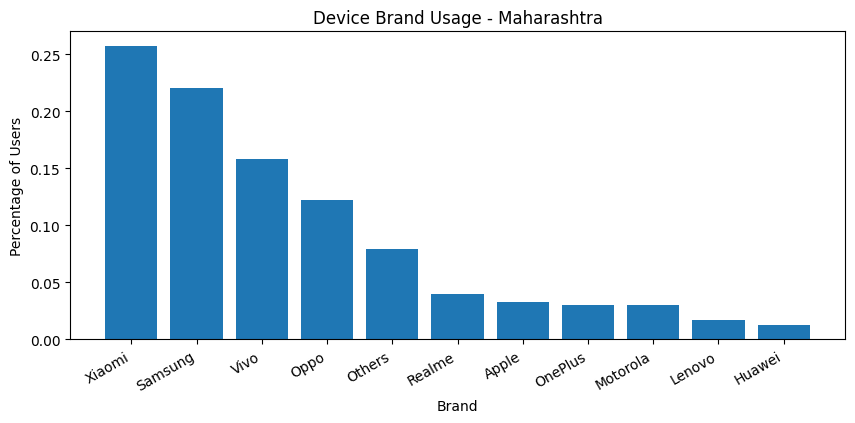

In [52]:
state_device =top_brand_ratio[top_brand_ratio['State']=='Maharashtra']

plt.figure(figsize=(10,4))
plt.bar(state_device['Brand'],state_device['Percentage'])
plt.xlabel('Brand')
plt.ylabel("Percentage of Users")
plt.title("Device Brand Usage - Maharashtra")
plt.xticks(rotation = 30, ha='right')
plt.show()

________

<h5> <center> Task 5: Data Visualization

_________

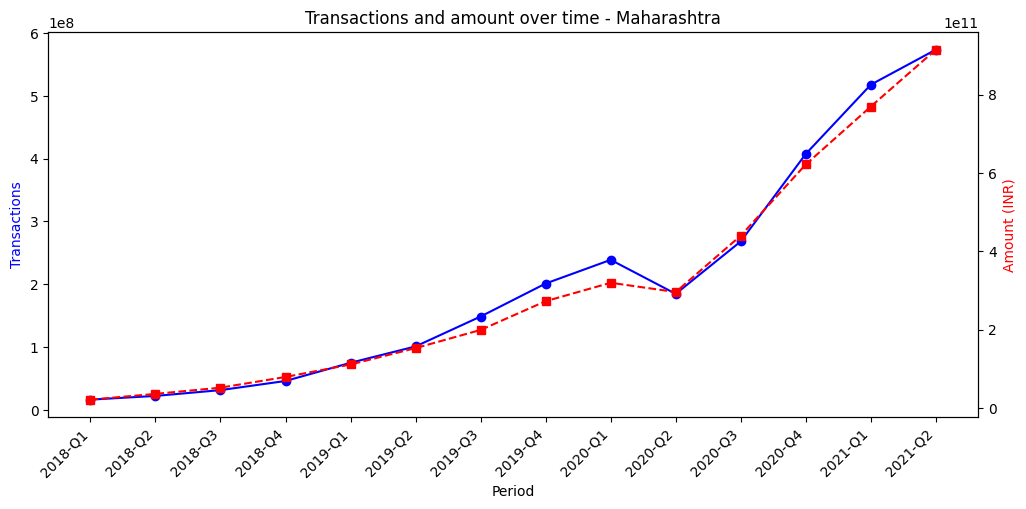

In [53]:
# line plot of transactions and amount over time for a selected state(MH)
state_ts = df_state[df_state['State']=='Maharashtra'].copy()
state_ts['Period'] =state_ts['Year'].astype(str) + "-Q" + state_ts['Quarter'].astype(str)
state_ts =state_ts.sort_values(['Year','Quarter'])

fig , ax1 =plt.subplots(figsize=(12,5))
ax2 =ax1.twinx()

ax1.plot(state_ts['Period'], state_ts["Transactions"],'b-o', label = "Transactions")
ax2.plot(state_ts['Period'], state_ts['Amount (INR)'], 'r--s', label ='Amount (INR)')

ax1.set_xlabel("Period")
ax1.set_ylabel("Transactions",color='blue')
ax2.set_ylabel("Amount (INR)", color ='red')
plt.title('Transactions and amount over time - Maharashtra')
# plt.xticks(rotation=45, ha='right')   This is getting applied to one axis and gets overridden by second one
ax1.set_xticks(range(len(state_ts['Period'])))
ax1.set_xticklabels(state_ts["Period"], rotation =45, ha='right')
plt.show()

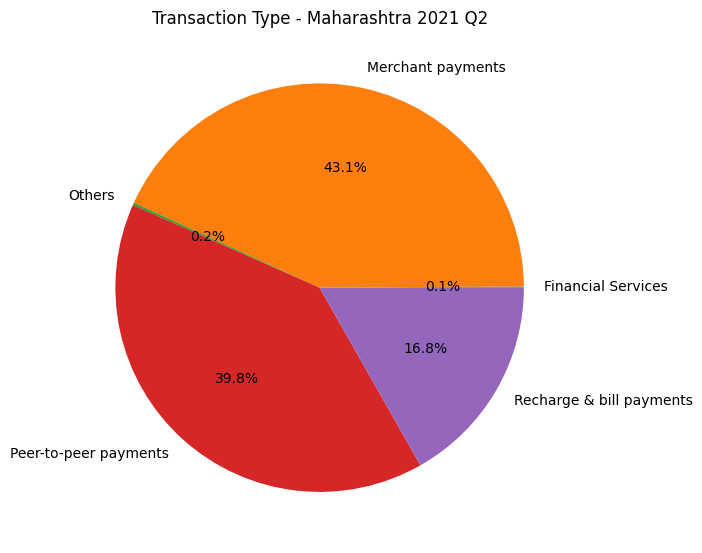

In [54]:
# Pie chart showing districbution of transaction types for specific quarter

pie_data = df_split[(df_split['State']=='Maharashtra') &
                    (df_split['Year']==latest_year) &
                    (df_split['Quarter'] ==latest_quarter)]

pie_values = pie_data.groupby("Transaction Type")['Transactions'].sum()

plt.figure(figsize =(7,7))
plt.pie(pie_values ,labels =pie_values.index, autopct = '%1.1f%%')
plt.title(f"Transaction Type - Maharashtra {latest_year} Q{latest_quarter}")
plt.tight_layout()          # this avoids any cutting of labels or title
plt.show()

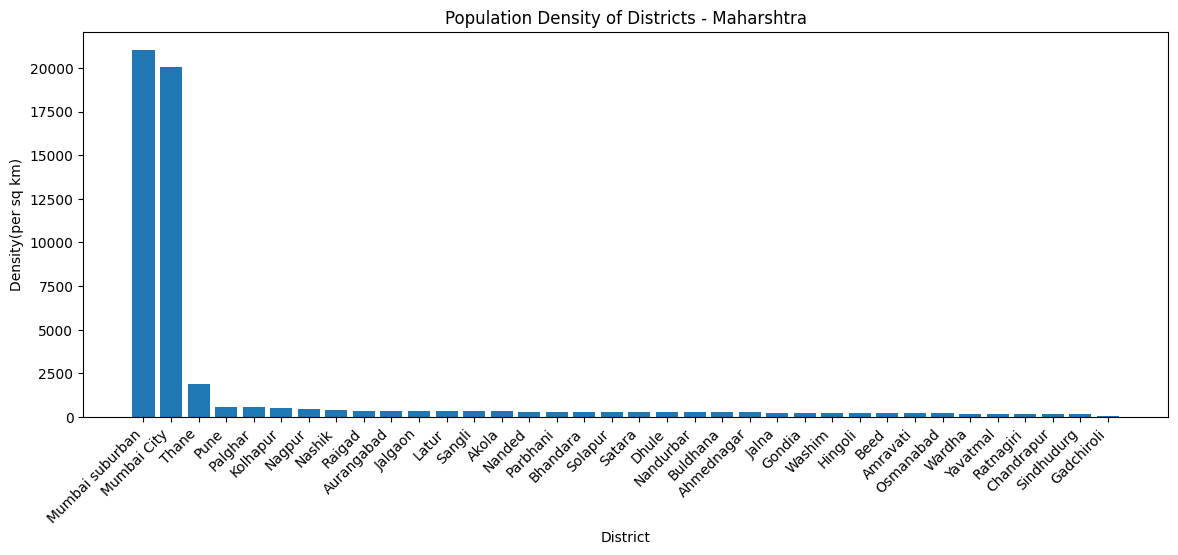

In [55]:
# population density of district in selected state
state_demo=df_dist_demo[df_dist_demo['State']=='Maharashtra'].copy()
state_demo = state_demo.sort_values('Density',ascending=False)

plt.figure(figsize=(14,5))
plt.bar(state_demo['District'],state_demo['Density'])
plt.xlabel("District")
plt.ylabel("Density(per sq km)")
plt.title('Population Density of Districts - Maharshtra')
plt.xticks(rotation =45,ha='right')
plt.show()

_________

<h5> <center> Task 6: Insights and Conclusion

-----

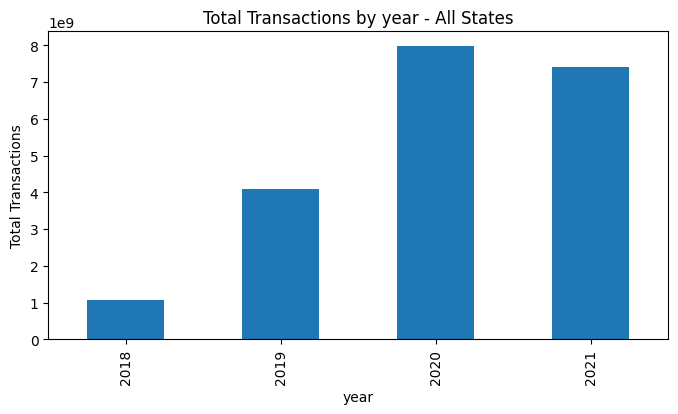

In [56]:
# Transaction Trend over Years

yearly = df_state.groupby('Year')['Transactions'].sum()

plt.figure(figsize=(8,4))
yearly.plot(kind = 'bar')
plt.xlabel('year')
plt.ylabel('Total Transactions')
plt.title("Total Transactions by year - All States")
plt.show()

In [57]:
print("""
Correlation Findings:
- Correlation between population density and transactions = 0.42
- Moderate positive relationship
- Denser districts tend to have more transactions
- But not always true - some low density districts also have high transactions
- Example: Bengaluru and Mumbai are outliers with very high transactions
""")


Correlation Findings:
- Correlation between population density and transactions = 0.42
- Moderate positive relationship
- Denser districts tend to have more transactions
- But not always true - some low density districts also have high transactions
- Example: Bengaluru and Mumbai are outliers with very high transactions



In [58]:
print("""
Key Findings:
1. Transactions grew 8x from 2018 to 2020
2. Peer-to-peer payments dominate nationally
3. Merchant payments dominate in Maharashtra
4. Delhi has highest user penetration at 66%
5. Xiaomi and Samsung are top devices across most states
6. North-eastern states are highly under-penetrated

Recommendations:
1. Focus on north-east states to grow user base
2. Push merchant payments in states where P2P dominates
3. Target Xiaomi and Samsung users for campaigns
4. Introduce rural-friendly features for low density districts
5. Leverage festive seasons for transaction growth
""")


Key Findings:
1. Transactions grew 8x from 2018 to 2020
2. Peer-to-peer payments dominate nationally
3. Merchant payments dominate in Maharashtra
4. Delhi has highest user penetration at 66%
5. Xiaomi and Samsung are top devices across most states
6. North-eastern states are highly under-penetrated

Recommendations:
1. Focus on north-east states to grow user base
2. Push merchant payments in states where P2P dominates
3. Target Xiaomi and Samsung users for campaigns
4. Introduce rural-friendly features for low density districts
5. Leverage festive seasons for transaction growth

